In [16]:
import pandas as pd
stations = pd.read_csv("../data/I5_S_pm_115_to_95/district12_stations.txt", sep="\t")
stations = stations[stations['Type']=='ML']
stations.head()

,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
2,1201054,133,S,12,59,36770.0,9,8.991,33.661840,-117.755300,1.285,ML,3,BARRANCA2,565,NaN,NaN,NaN
5,1201066,133,N,12,59,36770.0,9,8.991,33.661697,-117.754967,0.670,ML,2,BARRANCA1,551,NaN,NaN,NaN
7,1201076,133,N,12,59,36770.0,9.1,9.091,33.663305,-117.753976,0.185,ML,3,BARRANCA2,553,NaN,NaN,NaN
10,1201087,405,S,12,59,36770.0,.77,0.540,33.647015,-117.744091,0.180,ML,5,IRVINE C1,1414,NaN,NaN,NaN
13,1201100,405,N,12,59,36770.0,.93,0.700,33.648090,-117.746598,0.255,ML,5,IRVINE C1,1331,NaN,NaN,NaN


In [17]:
# group by FWY and Dir, then select only the rows with the min and max Abs_PM in each group
min_stations = stations.loc[stations.groupby(['Fwy', 'Dir'])['Abs_PM'].idxmin()]
max_stations = stations.loc[stations.groupby(['Fwy', 'Dir'])['Abs_PM'].idxmax()]

freeways = [133, 22, 241, 261, 405, 55, 57, 5, 605, 73, 91]

# only select rows where Fwy is in the freeways list
min_stations = min_stations[min_stations['Fwy'].isin(freeways)]
max_stations = max_stations[max_stations['Fwy'].isin(freeways)]

min_max_stations = pd.concat([min_stations, max_stations], ignore_index=False)
print(len(min_max_stations))
min_max_stations.head()

44


,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
667,1204198,5,N,12,59,65084.0,.65,72.908,33.405160,-117.597992,0.913,ML,4,S. LUIS REY,2611,NaN,NaN,NaN
666,1204193,5,S,12,59,65084.0,.64,72.835,33.404943,-117.598167,0.765,ML,4,S LUIS REY,2611,NaN,NaN,NaN
2118,1215965,22,E,12,59,70686.0,R.2,1.667,33.774295,-118.093885,0.602,ML,2,COLLEGE PARK,5047,NaN,NaN,NaN
2116,1215963,22,W,12,59,70686.0,R.2,1.667,33.774472,-118.093888,0.507,ML,2,COLLEGE PARK,5047,NaN,NaN,NaN
437,1203021,55,N,12,59,16532.0,R2.77,2.770,33.651784,-117.908497,2.650,ML,4,VICTORIA1,1824,NaN,NaN,NaN


In [14]:
min_max_stations[['Fwy','Dir','Abs_PM','Latitude','Longitude']].to_csv("../outputs/network/d12_network_extraction/corridor_end_coords.csv")

Get Aggregate Metrics for Thesis

In [22]:
# for each freeway in min_max_stations, get the length of the freeway by calculating the distance between the min and max Abs_PM for each freeway and direction
freeway_lengths = (
    min_max_stations.groupby(["Fwy", "Dir"])["Abs_PM"]
      .agg(lambda s: s.max() - s.min())
      .sort_index()
)
freeway_lengths
freeway_lengths.to_csv("../outputs/network/d12_network_extraction/freeway_lengths.csv")

In [25]:
from pathlib import Path
import pandas as pd

base_dir = Path("../outputs/network/d12_network_extraction")

rows = []

for corridor_dir in sorted(p for p in base_dir.iterdir() if p.is_dir()):
    nodes_path = corridor_dir / "gmns" / "node.csv"
    links_path = corridor_dir / "gmns" / "link.csv"
    
    if nodes_path.exists() and links_path.exists():
        node_count = len(pd.read_csv(nodes_path))
        edge_count = len(pd.read_csv(links_path))
        
        rows.append({
            "corridor": corridor_dir.name,
            "node_count": node_count,
            "edge_count": edge_count,
        })

corridor_counts_df = pd.DataFrame(rows).sort_values("corridor").reset_index(drop=True)

corridor_counts_df
# save to csv
corridor_counts_df.to_csv("../outputs/network/d12_network_extraction/corridor_node_edge_counts.csv", index=False)

In [83]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.geometry import box
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = "/Users/andrewmiller/Downloads/Latin_Modern-otf-2_006-12_08_2025/lmroman12-regular.otf"
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

print(prop.get_name())  # see the actual family name

plt.rcParams["font.family"] = prop.get_name()

base_dir = Path("../outputs/network/d12_network_extraction")

direction_priority = {"N": 0, "E": 1, "S": 2, "W": 3}

all_paths = sorted(base_dir.glob("*/clipped_mainline.geojson"))

corridor_records = []
for path in all_paths:
    corridor_full = path.parent.name
    if "_" not in corridor_full:
        continue
    corridor_base, direction = corridor_full.rsplit("_", 1)
    corridor_records.append({
        "corridor_full": corridor_full,
        "corridor_base": corridor_base,
        "direction": direction,
        "priority": direction_priority.get(direction, 99),
        "path": path,
    })

corridor_df = pd.DataFrame(corridor_records)

selected = (
    corridor_df.sort_values(["corridor_base", "priority"])
    .drop_duplicates(subset="corridor_base", keep="first")
    .sort_values("corridor_base")
)

gdfs = []
for _, row in selected.iterrows():
    gdf = gpd.read_file(row["path"])
    gdf["corridor"] = row["corridor_base"]
    gdfs.append(gdf[["corridor", "geometry"]])

corridors = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    geometry="geometry",
    crs="EPSG:4326",
)

counties = gpd.read_file("../data/ca_counties/CA_Counties.shp")
roads = gpd.read_file("../data/tl_2022_06_prisecroads/tl_2022_06_prisecroads.shp")
cities = gpd.read_file(
    "../data/California_Cities_and_Identifiers_Blue_Version_view_-4534362023006352347/"
    "California_City_Boundaries_and_Identifiers.shp"
)

major_roads = roads[roads["MTFCC"].isin(["S1100", "S1200"])].copy()

plot_crs = "EPSG:3310"
counties = counties.to_crs(plot_crs)
orange = counties[counties["NAME"] == "Orange"].copy()
ca_outline = counties.dissolve()

major_roads = major_roads.to_crs(plot_crs)
corridors = corridors.to_crs(plot_crs)
cities = cities.to_crs(plot_crs)

# Keep city boundaries in/near Orange County for context
city_bounds = orange.total_bounds
pad = 25000
cities_local = cities.cx[
    city_bounds[0] - pad : city_bounds[2] + pad,
    city_bounds[1] - pad : city_bounds[3] + pad,
].copy()

# Ocean polygon around California
xmin_s, ymin_s, xmax_s, ymax_s = ca_outline.total_bounds
ocean_rect = gpd.GeoDataFrame(
    geometry=[box(xmin_s - 300000, ymin_s - 300000, xmax_s + 300000, ymax_s + 300000)],
    crs=plot_crs,
)
ocean = gpd.overlay(ocean_rect, ca_outline.reset_index()[["geometry"]], how="difference")

LMRoman12


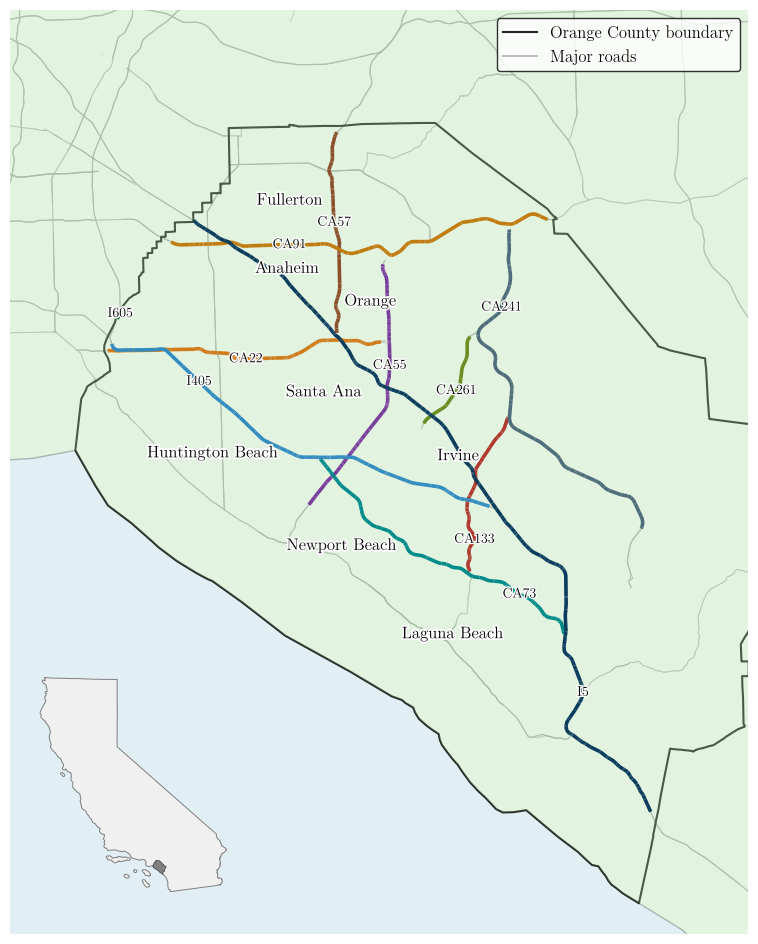

In [87]:
import matplotlib.patheffects as pe
from shapely.ops import linemerge

fig, ax = plt.subplots(figsize=(10, 12))

# Background layers
ocean.plot(
    ax=ax,
    color="#9ecae1",
    alpha=0.30,
    edgecolor="none",
    zorder=0,
)

ca_outline.plot(
    ax=ax,
    color="#a1d99b",
    alpha=0.3,
    edgecolor="#2b2b2b",
    linewidth=1,
    zorder=3,
)


orange.boundary.plot(
    ax=ax,
    color="#222222",
    linewidth=1.5,
    zorder=2.5,
)

major_roads.plot(
    ax=ax,
    color="#b0b0b0",
    linewidth=0.7,
    alpha=0.55,
    zorder=2,
)

# More professional corridor palette
corridor_colors = {
    "I5": "#0b3c5d",
    "I405": "#328cc1",
    "I605": "#2e6f40",
    "CA91": "#c27b0e",
    "CA57": "#8c4f2b",
    "CA55": "#7a3e9d",
    "CA73": "#008b8b",
    "CA133": "#b03a2e",
    "CA241": "#4f6d7a",
    "CA261": "#6b8e23",
    "CA22": "#d17c1b",
}


label_fractions = {
    "I5": 0.2,
    "I405": 0.76,
    "I605": 0.72,
    "CA91": 0.30,
    "CA57": 0.55,
    "CA55": 0.62,
    "CA73": 0.2,
    "CA133": 0.20,
    "CA241": 0.8,
    "CA261": 0.45,
    "CA22": 0.5,
}

for corridor in sorted(corridors["corridor"].unique()):
    subset = corridors[corridors["corridor"] == corridor]
    color = corridor_colors.get(corridor, "#4c566a")

    subset.plot(
        ax=ax,
        color=color,
        linewidth=2.6,
        alpha=1.0,
        zorder=4,
    )

    merged = subset.geometry.union_all()
    line = linemerge(merged)

    if line.geom_type == "MultiLineString":
        line = max(line.geoms, key=lambda g: g.length)

    frac = label_fractions.get(corridor, 0.5)
    pt = line.interpolate(frac, normalized=True)

    ax.text(
        pt.x,
        pt.y,
        corridor,
        fontsize=10,
        weight="bold",
        color="black",
        ha="center",
        va="center",
        zorder=5,
        path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.95)],
    )


# City labels only, no visible city boundary linework
city_label_names = [
    "Huntington Beach",
    "Newport Beach",
    "Anaheim",
    "Irvine",
    "Santa Ana",
    "Fullerton",
    "Laguna Beach",
    "Orange",

]

city_name_col = "CDTFA_CITY"  # adjust if you prefer a different name field
cities_labels = cities[cities[city_name_col].isin(city_label_names)].copy()

for _, row in cities_labels.iterrows():
    pt = row.geometry.representative_point()
    ax.text(
        pt.x,
        pt.y,
        row[city_name_col],
        fontsize=12,
        color="black",
        weight="bold",
        ha="center",
        va="center",
        zorder=4.5,
        path_effects=[pe.withStroke(linewidth=2.5, foreground="white", alpha=0.95)],
    )


# Extent
xmin, ymin, xmax, ymax = corridors.total_bounds
pad_x = 0.18 * (xmax - xmin)
pad_y = 0.18 * (ymax - ymin)

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)
ax.set_aspect("equal")
ax.set_axis_off()

# Legend
legend_handles = [
    Line2D([0], [0], color="#222222", lw=1.5, label="Orange County boundary"),
    Line2D([0], [0], color="#b0b0b0", lw=1.2, label="Major roads"),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=12,
)

# Grayscale inset
axins = inset_axes(ax, width="28%", height="28%", loc="lower left", borderpad=1.2)
ca_outline.plot(ax=axins, color="#f0f0f0", edgecolor="#7f7f7f", linewidth=0.7, zorder=1)
orange.plot(ax=axins, color="#7f7f7f", edgecolor="#4d4d4d", linewidth=0.5, zorder=2)

axins.set_xlim(xmin_s - 50000, xmax_s + 50000)
axins.set_ylim(ymin_s - 50000, ymax_s + 50000)
axins.set_aspect("equal")
axins.set_axis_off()

# plt.tight_layout()
output_path = "../outputs/network/d12_corridor_extractions_map.pdf"
plt.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()